# Agents: Controlling Expansion

In pSprout, agents traverse and expand / modify your space. A shared lifecycle applies modifications to each molecule in the current frontier, selects proposals, realizes the selected products in the `Space`, and returns the next `AgentState`.

This notebook compares exhaustive, random-walk, and beam-search policies on the same small starting space.

In [5]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from psprout import (
    Space,
    ExhaustiveExpansionAgent,
    RandomWalkAgent,
    BeamSearchAgent,
    DescriptorTargetMetric,
    Objective,
)
from psprout.modifications import ModificationLibrary

support_molecules=["c1ccccc1"]
exhaustive_space = Space(support_molecules=support_molecules)
lib = ModificationLibrary.load("simple")
modifications = [lib.AddHydroxyl, lib.AddFormyl, lib.AddAmino]

[exhaustive_history, exhaustive_agent] = exhaustive_space.run_agent(ExhaustiveExpansionAgent, modifications, max_iterations=3)
exhaustive_history


,iteration,frontier_size,visited_size,node_count,edge_count
0,1,3,4,4,3
1,2,27,31,31,30
2,3,169,200,200,199


## A few agents and their policies

- `ExhaustiveExpansionAgent` realizes every proposal (keeps every generated molecule). It is appropriate only for small, complete explorations.
- `RandomWalkAgent` samples `k` proposals per frontier molecule. Its seed makes uniform sampling reproducible.
- `BeamSearchAgent` scores every proposal with an `Objective` and retains the highest-scoring `beam_width` number of proposals.

The agent's `propose()`, `select()`, and `realize()` methods separate candidate generation, policy choice, and graph mutation. `advance()` performs one complete iteration.

In [6]:
random_space = Space(support_molecules=support_molecules)

[random_history, random_agent] = random_space.run_agent(
    RandomWalkAgent,
    modifications=modifications,
    max_iterations=3,
    k=1,
    seed=42,
)

# Reward products whose molecular weight is close to 110 Da.
objective = Objective(
    {"target_weight": (DescriptorTargetMetric("exact_mol_wt", target=110.0), 1.0)}
)

beam_space = Space(support_molecules=support_molecules)
[beam_history, beam_agent] = beam_space.run_agent(
    BeamSearchAgent,
    modifications=modifications,
    max_iterations=3,
    objective=objective,
    beam_width=3,
)

comparison = pd.concat(
    [
        exhaustive_history.assign(agent="exhaustive"),
        random_history.assign(agent="random walk"),
        beam_history.assign(agent="beam search"),
    ],
    ignore_index=True,
)
comparison

,iteration,frontier_size,visited_size,node_count,edge_count,agent
0,1,3,4,4,3,exhaustive
1,2,27,31,31,30,exhaustive
2,3,169,200,200,199,exhaustive
3,1,1,2,2,1,random walk
4,2,1,3,3,2,random walk
5,3,1,4,4,3,random walk
6,1,3,4,4,3,beam search
7,2,3,7,7,6,beam search
8,3,3,10,10,9,beam search


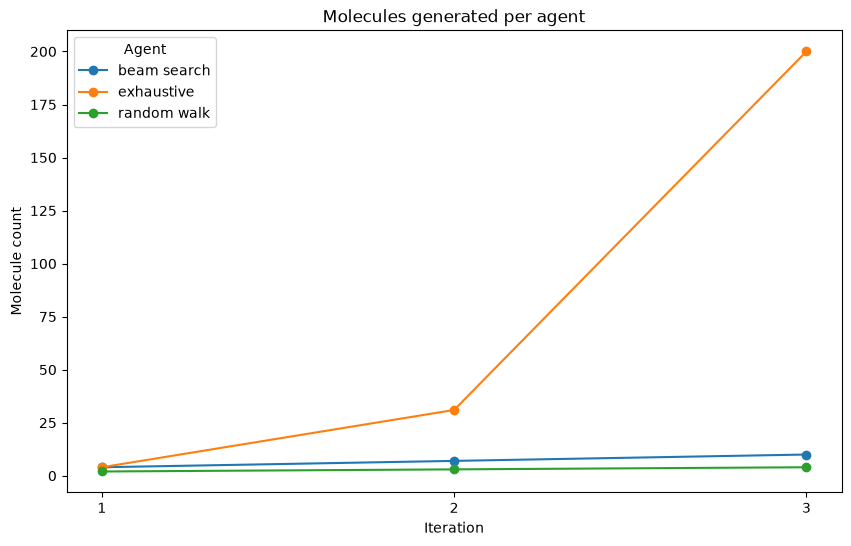

In [7]:
# plot the number of unique molecules generated by each agent over time
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(10, 6))
for agent_name, group in comparison.groupby("agent"):
    ax.plot(group["iteration"], group["node_count"], marker="o", label=agent_name)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Iteration")
ax.set_ylabel("Molecule count")
ax.set_title("Molecules generated per agent")
ax.legend(title="Agent")

## Inspect the resulting state

The history table records how each policy changes the frontier and graph size. Because `Space` exposes its NetworkX graph, standard graph queries can inspect connectivity. Node records carry canonical SMILES, metadata, and descriptors.

In [8]:
graph = beam_space.get_graph()
node_table = pd.DataFrame(
    [
        {
            "smiles": node_id,
            "node_type": data["molecule"].metadata.get("type", "generated"),
            **data["molecule"].descriptors,
        }
        for node_id, data in graph.nodes(data=True)
    ]
)

print(node_table[["smiles", "node_type", "exact_mol_wt", "logp"]])
print(f"Weakly connected components: {nx.number_weakly_connected_components(graph)}")
print(f"Out-degrees: {dict(graph.out_degree())}")

          smiles  node_type  exact_mol_wt    logp
0       c1ccccc1    support     78.046950  1.6866
1    O=Cc1ccccc1  generated    106.041865  1.4991
2      Oc1ccccc1  generated     94.041865  1.3922
3      Nc1ccccc1  generated     93.057849  1.2688
4     OOc1ccccc1  generated    110.036779  1.5384
5     Oc1ccccc1O  generated    110.036779  1.0978
6   Oc1cccc(O)c1  generated    110.036779  1.0978
7    NOOc1ccccc1  generated    125.047678  0.8707
8    Nc1ccccc1OO  generated    125.047678  1.1206
9  Nc1cccc(OO)c1  generated    125.047678  1.1206
Weakly connected components: 1
Out-degrees: {'c1ccccc1': 3, 'O=Cc1ccccc1': 0, 'Oc1ccccc1': 3, 'Nc1ccccc1': 0, 'OOc1ccccc1': 3, 'Oc1ccccc1O': 0, 'Oc1cccc(O)c1': 0, 'NOOc1ccccc1': 0, 'Nc1ccccc1OO': 0, 'Nc1cccc(OO)c1': 0}
